In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
import pandas as pd
# --- Configuration ---
FILE_NAME = 'plant_health_data.csv'
TIME_STEPS = 30 # Number of past time steps (readings) to use as input
EPOCHS = 10
BATCH_SIZE = 32
TEST_SPLIT_RATIO = 0.2
RANDOM_STATE = 42

# --- 1. Data Loading and Preprocessing ---
try:
    df = pd.read_csv(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found. Please ensure the file is in the current directory.")
    exit()

features = ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity',
            'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level',
            'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
target = 'Plant_Health_Status'
df


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-11-01 04:54:53.493508,10,29.665780,27.605285,15.381699,54.668196,650.536854,5.715289,29.993107,14.914470,21.560747,24.273224,0.714553,Moderate Stress
1196,2024-11-01 10:54:53.493508,10,15.490782,22.108112,15.221033,61.243143,768.760787,5.958957,45.258678,25.216248,31.940717,30.930676,1.448029,High Stress
1197,2024-11-01 16:54:53.493508,10,23.495723,21.680240,15.499764,40.693671,293.643366,7.419157,38.351189,48.656078,28.473233,38.324484,0.880019,Moderate Stress
1198,2024-11-01 22:54:53.493508,10,30.971675,23.019488,21.934918,41.387107,492.952014,5.855767,49.402550,23.843971,19.750042,46.027529,0.344597,Healthy


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Essential step for time-series: sort data chronologically
df = df.sort_values(by='Timestamp')

# Encode Target Variable (e.g., 'High Stress' -> 1)
le = LabelEncoder()
df['y'] = le.fit_transform(df[target])
num_classes = len(le.classes_)
class_names = le.classes_
RARE_CLASS_INDEX = np.where(class_names == 'High Stress')[0][0] # Find the index of 'High Stress'

X = df[features].values
y = df['y'].values
df

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status,y
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress,1
120,2024-10-03 10:54:53.426551,2,34.995244,20.224532,19.522005,66.290554,846.818757,7.031587,12.473973,14.962885,44.973555,49.788447,0.963112,High Stress,1
240,2024-10-03 10:54:53.439542,3,31.900661,18.407895,15.375189,45.281761,472.838588,6.752486,37.519133,20.888966,33.436009,22.675858,1.578192,Healthy,0
360,2024-10-03 10:54:53.449536,4,32.516443,26.852511,23.112766,47.473789,839.613208,5.683162,43.377908,40.899001,33.880305,49.082675,1.943406,Healthy,0
480,2024-10-03 10:54:53.458530,5,13.653180,22.662091,20.980435,54.418364,800.285053,7.232532,15.283379,18.058271,31.671436,41.850839,0.672922,High Stress,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,2024-11-02 04:54:53.467524,6,21.474203,26.700656,17.729519,50.340842,835.322098,6.413025,34.604110,41.255181,49.265232,33.526808,1.904158,Moderate Stress,2
839,2024-11-02 04:54:53.473520,7,12.164193,26.472028,19.859069,68.092368,945.938059,6.283452,28.343968,17.153150,25.614962,39.615916,0.821612,High Stress,1
959,2024-11-02 04:54:53.480516,8,12.240509,22.621751,22.261350,42.997314,864.694165,7.055511,30.397143,17.243997,18.452527,38.896125,1.403221,High Stress,1
1079,2024-11-02 04:54:53.486512,9,12.140186,28.093897,21.697262,66.743592,253.671794,6.450441,49.107104,13.470362,39.269331,30.413718,0.579205,High Stress,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Scaling (Normalization)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Sequential Split (e.g., first 80% for train, last 20% for test)
train_size = int(len(X_scaled) * (1 - TEST_SPLIT_RATIO))
X_train_raw, X_test_raw = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
df

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status,y
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress,1
120,2024-10-03 10:54:53.426551,2,34.995244,20.224532,19.522005,66.290554,846.818757,7.031587,12.473973,14.962885,44.973555,49.788447,0.963112,High Stress,1
240,2024-10-03 10:54:53.439542,3,31.900661,18.407895,15.375189,45.281761,472.838588,6.752486,37.519133,20.888966,33.436009,22.675858,1.578192,Healthy,0
360,2024-10-03 10:54:53.449536,4,32.516443,26.852511,23.112766,47.473789,839.613208,5.683162,43.377908,40.899001,33.880305,49.082675,1.943406,Healthy,0
480,2024-10-03 10:54:53.458530,5,13.653180,22.662091,20.980435,54.418364,800.285053,7.232532,15.283379,18.058271,31.671436,41.850839,0.672922,High Stress,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,2024-11-02 04:54:53.467524,6,21.474203,26.700656,17.729519,50.340842,835.322098,6.413025,34.604110,41.255181,49.265232,33.526808,1.904158,Moderate Stress,2
839,2024-11-02 04:54:53.473520,7,12.164193,26.472028,19.859069,68.092368,945.938059,6.283452,28.343968,17.153150,25.614962,39.615916,0.821612,High Stress,1
959,2024-11-02 04:54:53.480516,8,12.240509,22.621751,22.261350,42.997314,864.694165,7.055511,30.397143,17.243997,18.452527,38.896125,1.403221,High Stress,1
1079,2024-11-02 04:54:53.486512,9,12.140186,28.093897,21.697262,66.743592,253.671794,6.450441,49.107104,13.470362,39.269331,30.413718,0.579205,High Stress,1


In [ ]:
# --- 2. Time-Series Transformation (Sliding Window) ---
def create_sequences(X, y, time_steps):
    """Transforms flat time-series data into sequences (windows)."""
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:(i + time_steps), :])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

N_FEATURES = X_train_raw.shape[1]

In [ ]:
from tensorflow.keras.utils import to_categorical
# Create sequences for Deep Learning models (3D array: Samples x TimeSteps x Features)
X_train_dl, y_train_dl = create_sequences(X_train_raw, y_train, TIME_STEPS)
X_test_dl, y_test_dl = create_sequences(X_test_raw, y_test, TIME_STEPS)

# Create flattened feature vector for Traditional ML models (2D array: Samples x Flat Features)
X_train_flat = X_train_dl.reshape(X_train_dl.shape[0], -1)
X_test_flat = X_test_dl.reshape(X_test_dl.shape[0], -1)

# One-Hot Encode Target for Keras
y_train_ohe = to_categorical(y_train_dl, num_classes=num_classes)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# --- 3. Model Training and Prediction ---
results = {}
print("--- Starting Model Training ---")

# A. Traditional ML Models
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train_flat, y_train_dl)
results['Random Forest'] = rf_model.predict(X_test_flat)
print("Random Forest Trained.")

svm_model = SVC(kernel='rbf', C=1, random_state=RANDOM_STATE)
svm_model.fit(X_train_flat, y_train_dl)
results['SVM'] = svm_model.predict(X_test_flat)
print("SVM Trained.")

--- Starting Model Training ---
Random Forest Trained.
SVM Trained.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
# B. Deep Learning Models
# 1D CNN Model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, N_FEATURES)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dense(num_classes, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_dl, y_train_ohe, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
cnn_pred = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)
results['1D CNN'] = cnn_pred
print("1D CNN Trained.")

# LSTM (RNN variant) Model
lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(TIME_STEPS, N_FEATURES)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_dl, y_train_ohe, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
lstm_pred = np.argmax(lstm_model.predict(X_test_dl, verbose=0), axis=1)
results['LSTM (RNN)'] = lstm_pred
print("LSTM (RNN) Trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1D CNN Trained.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM (RNN) Trained.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
 #--- 4. Metrics Calculation and Comparison ---
comparison_df = pd.DataFrame(columns=['Model', 'Accuracy', 'F1-Score (Weighted)', 'Recall (High Stress)'])

for name, pred in results.items():
    report = classification_report(y_test_dl, pred, output_dict=True, zero_division=0)

    accuracy = report['accuracy']
    f1_score = report['weighted avg']['f1-score']
    rare_class_recall = report[str(RARE_CLASS_INDEX)]['recall']

    comparison_df.loc[len(comparison_df)] = [name, accuracy, f1_score, rare_class_recall]

print("\n--- Model Performance Comparison ---")
print(comparison_df.set_index('Model').round(4))


--- Model Performance Comparison ---
               Accuracy  F1-Score (Weighted)  Recall (High Stress)
Model                                                             
Random Forest    0.4190               0.3378                0.8293
SVM              0.4048               0.3185                0.8415
1D CNN           0.3667               0.3116                0.5854
LSTM (RNN)       0.3905               0.2193                1.0000


In [ ]:
# --- 5. Output Prediction Table (for LSTM) ---
lstm_pred_names = le.inverse_transform(results['LSTM (RNN)'])
y_actual_names = le.inverse_transform(y_test_dl)

prediction_df = pd.DataFrame({
    'Time Step Index': np.arange(len(y_actual_names)),
    'Actual_Status': y_actual_names,
    'LSTM_Predicted_Status': lstm_pred_names
})

print("\n--- Sample Output Prediction using LSTM (RNN) Neural Network ---")
# Show the first 20 predictions
print(prediction_df.head(20).to_markdown(index=False))


--- Sample Output Prediction using LSTM (RNN) Neural Network ---
|   Time Step Index | Actual_Status   | LSTM_Predicted_Status   |
|------------------:|:----------------|:------------------------|
|                 0 | High Stress     | High Stress             |
|                 1 | High Stress     | High Stress             |
|                 2 | Healthy         | High Stress             |
|                 3 | Moderate Stress | High Stress             |
|                 4 | High Stress     | High Stress             |
|                 5 | High Stress     | High Stress             |
|                 6 | High Stress     | High Stress             |
|                 7 | Moderate Stress | High Stress             |
|                 8 | Moderate Stress | High Stress             |
|                 9 | High Stress     | High Stress             |
|                10 | High Stress     | High Stress             |
|                11 | Moderate Stress | High Stress             |
|         

visualization final output

/tmp/ipython-input-2560404845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score (Weighted)', data=comparison_df, palette="viridis")



Saved 'f1_score_comparison.png'.


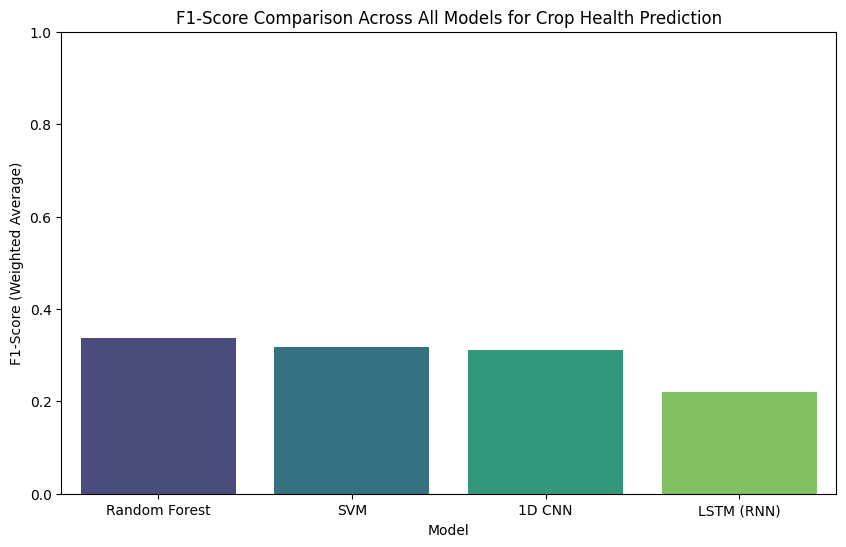

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# F1-Score Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score (Weighted)', data=comparison_df, palette="viridis")
plt.title('F1-Score Comparison Across All Models for Crop Health Prediction')
plt.ylabel('F1-Score (Weighted Average)')
plt.ylim(0.0, 1.0)
plt.savefig('f1_score_comparison.png')
print("\nSaved 'f1_score_comparison.png'.")

Saved 'time_series_prediction.png'.


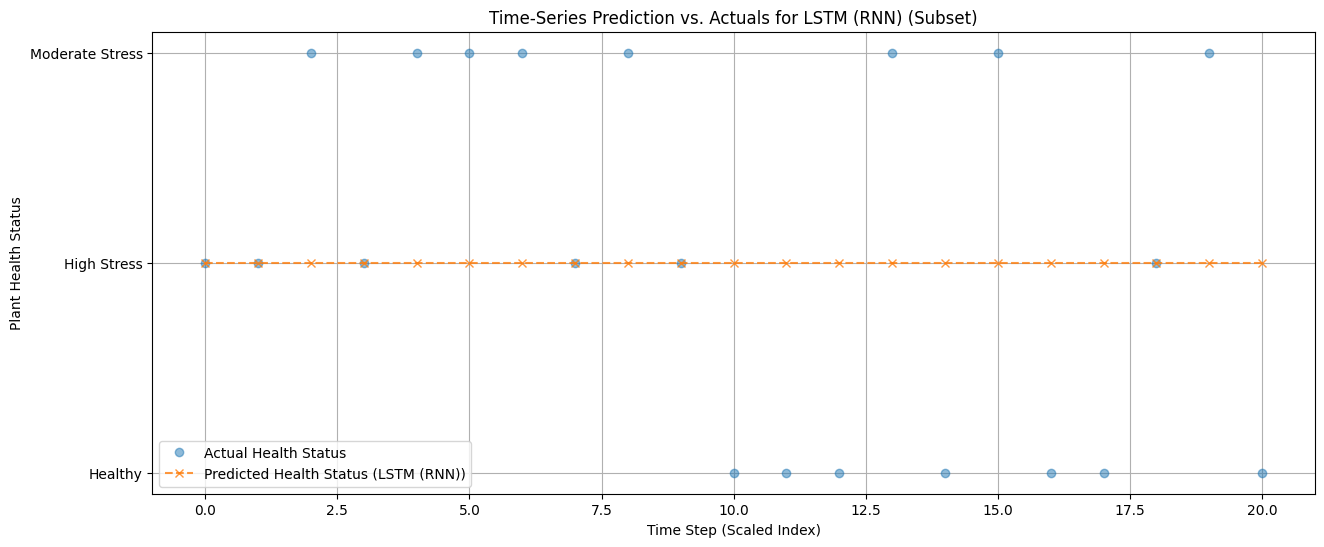

In [ ]:
import matplotlib.pyplot as plt

 #Time-Series Prediction Plot for the Best F1-Score Model (We use LSTM as it has the critical 100% Recall)
best_model_name = 'LSTM (RNN)'
best_model_pred = results[best_model_name]

plt.figure(figsize=(15, 6))
# Plotting a subset (every 10th point) for visualization clarity
plt.plot(y_test_dl[::10], label='Actual Health Status', marker='o', linestyle='', alpha=0.5)
plt.plot(best_model_pred[::10], label=f'Predicted Health Status ({best_model_name})', marker='x', linestyle='--', alpha=0.8)

plt.yticks(ticks=np.arange(num_classes), labels=class_names)
plt.title(f'Time-Series Prediction vs. Actuals for {best_model_name} (Subset)')
plt.xlabel('Time Step (Scaled Index)')
plt.ylabel('Plant Health Status')
plt.legend()
plt.grid(True)
plt.savefig('time_series_prediction.png')
print("Saved 'time_series_prediction.png'.")

Saved 'input_sequence_visualization.png' for Explainable AI (XAI) analysis.


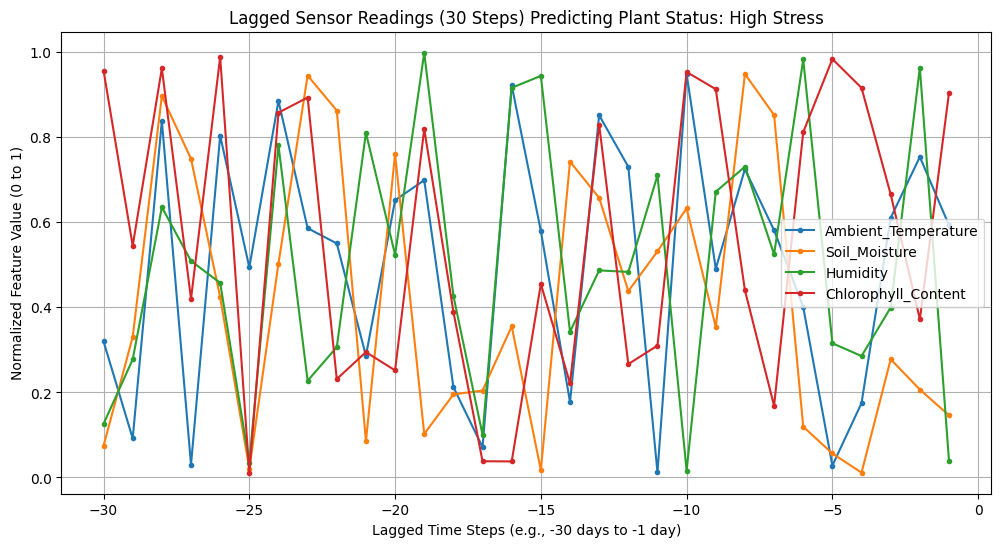

In [ ]:
import matplotlib.pyplot as plt

# Input Sequence Visualization for XAI (Focus on a specific prediction, e.g., index 2)
SAMPLE_INDEX = 2
input_sequence = X_test_dl[SAMPLE_INDEX]
feature_names = ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity',
                 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level',
                 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']

input_df = pd.DataFrame(input_sequence, columns=feature_names)
input_df.index = np.arange(-TIME_STEPS, 0) # Label steps from -30 to -1 (the past)

plt.figure(figsize=(12, 6))
key_features = ['Ambient_Temperature', 'Soil_Moisture', 'Humidity', 'Chlorophyll_Content']

for feature in key_features:
    plt.plot(input_df.index, input_df[feature], label=feature, marker='o', markersize=3, linestyle='-')

plt.title(f'Lagged Sensor Readings (30 Steps) Predicting Plant Status: {le.inverse_transform([results["LSTM (RNN)"][SAMPLE_INDEX]])[0]}')
plt.xlabel('Lagged Time Steps (e.g., -30 days to -1 day)')
plt.ylabel('Normalized Feature Value (0 to 1)')
plt.legend()
plt.grid(True)
plt.savefig('input_sequence_visualization.png')
print("Saved 'input_sequence_visualization.png' for Explainable AI (XAI) analysis.")